In [1]:
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1c_extended_curatedsets"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df["N_features"] = df["N_features"] = df["features"].str.extract(r"RFE_(\d+)_permute")

In [2]:
val_df = df[df.dataset == "val"]
dmm_val_df = val_df[val_df.ref == "DMM"]
# val_df.features.fillna("None", inplace=True)

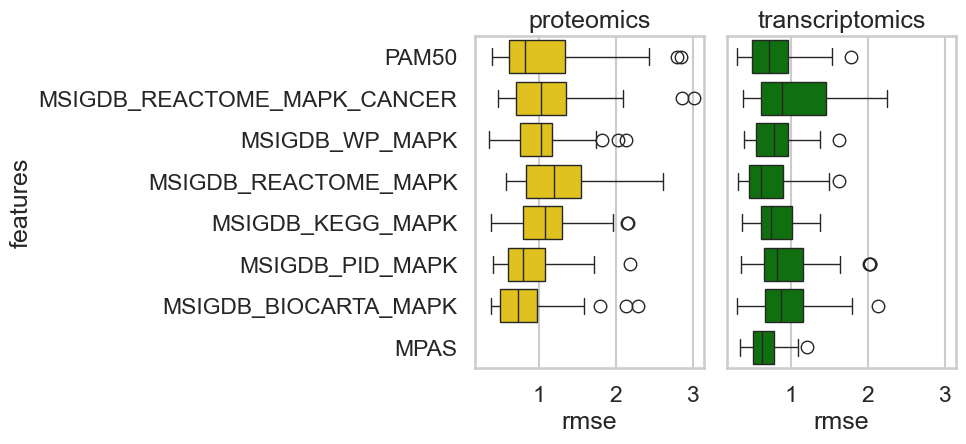

In [3]:
import matplotlib.pyplot as plt
# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "magenta",
}

g = sns.FacetGrid(
    dmm_val_df[
        (dmm_val_df.context.isin(["proteomics", "transcriptomics"])) &
        (dmm_val_df.features.isin([
            "MPAS",
            "PAM50",
            "MSIGDB_KEGG_MAPK",
            "MSIGDB_BIOCARTA_MAPK",
            "MSIGDB_PID_MAPK",
            "MSIGDB_REACTOME_MAPK",
            "MSIGDB_REACTOME_MAPK_CANCER",
            "MSIGDB_WP_MAPK",
        ]))
    ],
    col="context",
    col_order=["proteomics", "transcriptomics"],
    col_wrap=2,
    sharey=True,
    despine=False,
    height=5,
)

g.map_dataframe(
    sns.boxplot,
    x="rmse",
    y="features",
    hue="context",
    palette=palette
)

# Add axis labels and titles
# g.set_axis_labels("Number of Selected Features", "Validation RMSE")
g.set_titles(col_template="{col_name}")

# Adjust layout
plt.subplots_adjust(top=0.85, wspace=0.10)
# plt.savefig("feature_selection.svg")
plt.show()

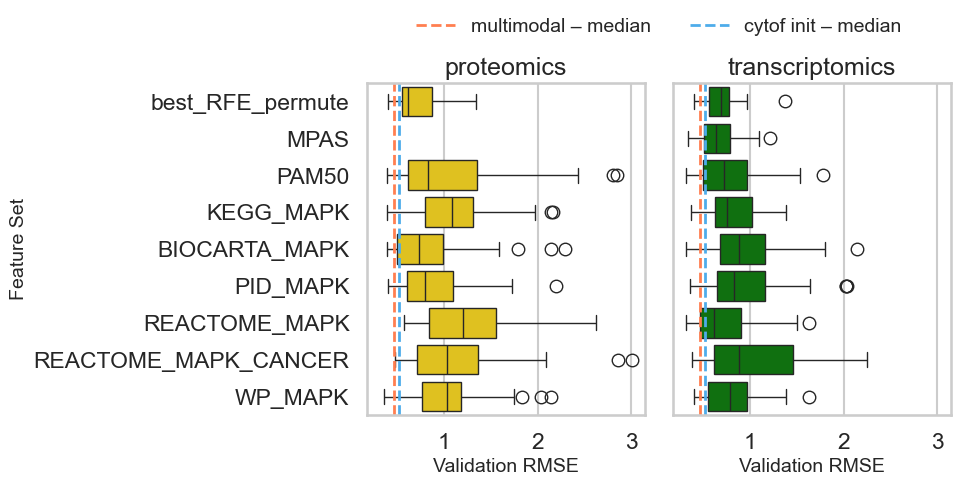

In [7]:
import matplotlib.pyplot as plt
# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "magenta",
}

plot_df = dmm_val_df.copy()
plot_df["features"] = plot_df["features"].str.replace("^MSIGDB_", "", regex=True)

best_proteomics = plot_df[((plot_df.context == "proteomics") & (plot_df.features == "HVGRFE_25_permute"))]
best_proteomics["features"] = "best_RFE_permute"
best_transcriptomics = plot_df[((plot_df.context == "transcriptomics") & (plot_df.features == "HVGRFE_20_permute"))]
best_transcriptomics["features"] = "best_RFE_permute"

plot_df = pd.concat([plot_df, best_proteomics, best_transcriptomics])


g = sns.FacetGrid(
    plot_df[
        (plot_df.context.isin(["proteomics", "transcriptomics"])) &
        (plot_df.features.isin([
            "best_RFE_permute",
            "MPAS",
            "PAM50",
            "KEGG_MAPK",
            "BIOCARTA_MAPK",
            "PID_MAPK",
            "REACTOME_MAPK",
            "REACTOME_MAPK_CANCER",
            "WP_MAPK",
        ]))
    ],
    col="context",
    col_order=["proteomics", "transcriptomics"],
    col_wrap=2,
    sharey=True,
    despine=False,
    height=5,
)

g.map_dataframe(
    sns.boxplot,
    x="rmse",
    y="features",
    order=[
        "best_RFE_permute",
        "MPAS",
        "PAM50",
        "KEGG_MAPK",
        "BIOCARTA_MAPK",
        "PID_MAPK",
        "REACTOME_MAPK",
        "REACTOME_MAPK_CANCER",
        "WP_MAPK",
    ],
    hue="context",
    palette=palette
)

# Add vlines
for ax in g.axes.flat:
    ax.axvline(0.462043, color="coral", linestyle="--", linewidth=2)
    # ax.text(0.462043, 0.95, "multimodal", color="coral",
    #         ha="right", va="top", rotation=90, transform=ax.get_xaxis_transform())

    ax.axvline(0.519751, color=(78/255, 172/255, 234/255), linestyle="--", linewidth=2)
    # ax.text(0.519751, 0.95, "cytof_init", color="cyan",
    #         ha="left", va="top", rotation=90, transform=ax.get_xaxis_transform())

    ax.set_xlabel("Validation RMSE", fontsize=14)
    ax.set_ylabel("Feature Set", fontsize=14)

# Build a custom legend with label + value
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color="coral", linestyle="--", lw=2,
           label=f"multimodal – median"),
    Line2D([0], [0], color=(78/255, 172/255, 234/255), linestyle="--", lw=2,
           label=f"cytof init – median"),
]
plt.legend(
    handles=handles,
    loc="upper center",         # put legend at the top
    bbox_to_anchor=(-0.05, 1.25), # center horizontally, shift up
    ncol=2,                     # put items side by side
    frameon=False,
    fontsize=14
)

g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.85, wspace=0.10)
plt.savefig("curated_feature_sets_1c_expanded.svg")
plt.show()

In [20]:
 from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [21]:
kruskal_wallis_groups(
    dmm_val_df[dmm_val_df.N_features <= 15],
    "rmse",
    "N_features",
    "context"
)

Context/Group: proteomics - Kruskal-Wallis H-test: H-statistic=10.38, p-value=0.0056, significant? True
Context/Group: transcriptomics - Kruskal-Wallis H-test: H-statistic=8.86, p-value=0.0119, significant? True
Context/Group: multimodal - Kruskal-Wallis H-test: H-statistic=9.39, p-value=0.0092, significant? True
Context/Group: cytof_init - Kruskal-Wallis H-test: H-statistic=21.42, p-value=0.0000, significant? True


Not significant for cytof_init or transcriptomics. multimodal only gets worse. proteomics is the only context where there seems to be an honest and significant benefit in using more features - is it just that feature selection cannot find relevant features at all and this increases the chances of finding remotely useful ones?